<a href="https://colab.research.google.com/github/hamzaalnajjar/SalesPredictionModel/blob/main/ProgrammingAssignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<ipython-input-11-c5c8645d0d6c>:32: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_volume = stock_data['Volume'].resample('M').mean()


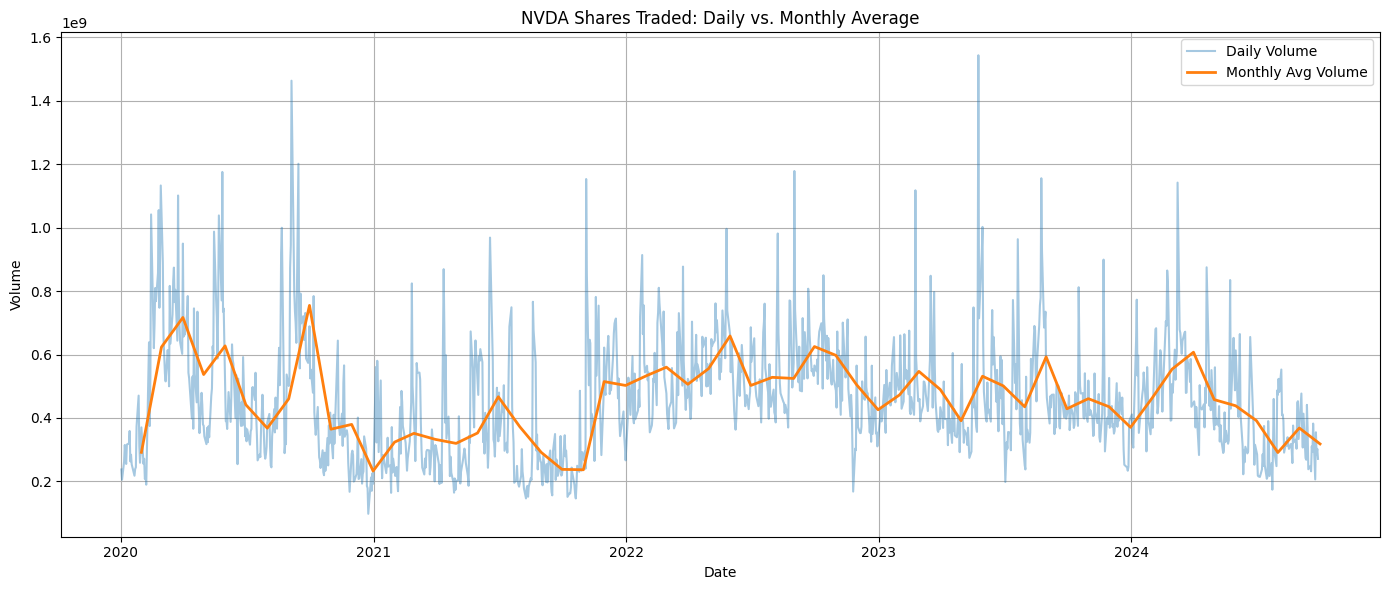

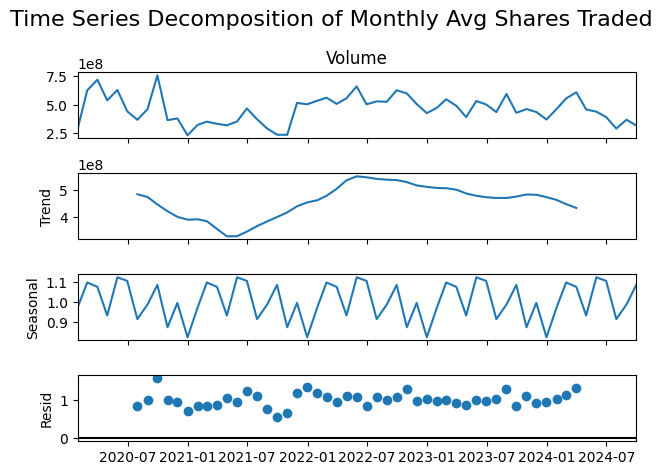

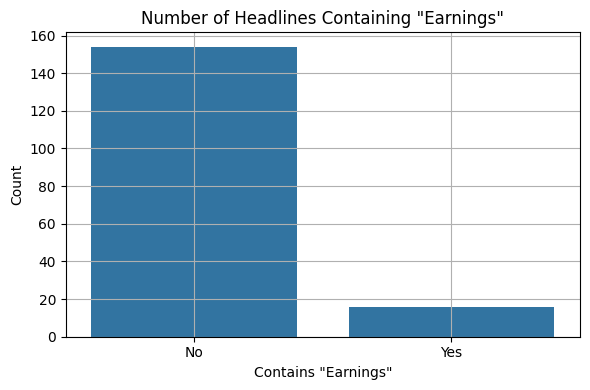

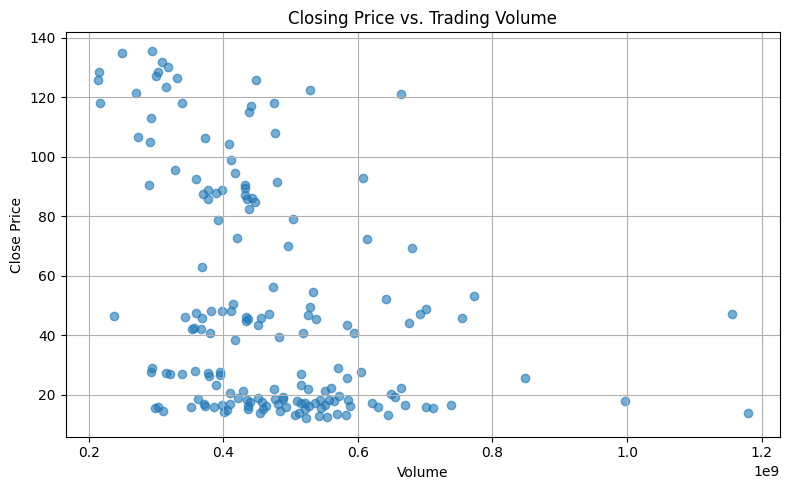

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[NbConvertApp] Converting notebook /content/ProgrammingAssignment2.ipynb to html
[NbConvertApp] Writing 292124 bytes to /content/ProgrammingAssignment2.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#connect drive
from google.colab import drive
drive.mount('/content/drive')


#1: loading data from drive
import pandas as pd

csv_path_1 = '/content/drive/My Drive/NVDA_daily_data.csv'
csv_path_2 = '/content/drive/My Drive/nvda_news_headlines.csv'

stock_data = pd.read_csv(csv_path_1)
news_data = pd.read_csv(csv_path_2)

stock_data.head(), news_data.head()

#2: converting date columns + set ind
stock_data['Date'] = pd.to_datetime(stock_data['Date'])
news_data['Date'] = pd.to_datetime(news_data['Date'])

stock_data.set_index('Date', inplace=True)
news_data.set_index('Date', inplace=True)

stock_data.index = stock_data.index.normalize()
news_data.index = news_data.index.normalize()

stock_data.head(), news_data.head()

#3: time series aggregation
import matplotlib.pyplot as plt

monthly_volume = stock_data['Volume'].resample('M').mean()

plt.figure(figsize=(14, 6))
plt.plot(stock_data['Volume'], label='Daily Volume', alpha=0.4)
plt.plot(monthly_volume, label='Monthly Avg Volume', linewidth=2)
plt.title('NVDA Shares Traded: Daily vs. Monthly Average')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


#4: time series decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(monthly_volume, model='multiplicative')
decomposition.plot()
plt.suptitle('Time Series Decomposition of Monthly Avg Shares Traded', fontsize=16)
plt.tight_layout()
plt.show()

#5: regex-based feature extraction
import re

news_data['Contains_Earnings'] = news_data['Headline'].str.contains(r'\bearnings\b', flags=re.IGNORECASE, regex=True)
news_data['Contains_Percent'] = news_data['Headline'].str.contains(r'\d+%', regex=True)
news_data['Contains_Dollar'] = news_data['Headline'].str.contains(r'\$\d+', regex=True)

news_data['Contains_Earnings'] = news_data['Contains_Earnings'].map({True: 'Yes', False: 'No'})
news_data['Contains_Percent'] = news_data['Contains_Percent'].map({True: 'Yes', False: 'No'})
news_data['Contains_Dollar'] = news_data['Contains_Dollar'].map({True: 'Yes', False: 'No'})

news_data.head()

#6: merge stock + news data
merged_data = pd.merge(stock_data, news_data, left_index=True, right_index=True, how='inner')
merged_data.head()

#7: data visualization
import seaborn as sns

#bar plot
plt.figure(figsize=(6, 4))
sns.countplot(data=merged_data, x='Contains_Earnings')
plt.title('Number of Headlines Containing "Earnings"')
plt.xlabel('Contains "Earnings"')
plt.ylabel('Count')
plt.grid(True)
plt.tight_layout()
plt.show()

#scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(merged_data['Volume'], merged_data['Close'], alpha=0.6)
plt.title('Closing Price vs. Trading Volume')
plt.xlabel('Volume')
plt.ylabel('Close Price')
plt.grid(True)
plt.tight_layout()
plt.show()


#converting + download
from google.colab import drive
drive.mount('/content/drive')

!cp "/content/drive/My Drive/Colab Notebooks/ProgrammingAssignment2.ipynb" "/content/ProgrammingAssignment2.ipynb"

#convert html
!jupyter nbconvert --to html "/content/ProgrammingAssignment2.ipynb"

#download to mac
from google.colab import files
files.download("/content/ProgrammingAssignment2.html")








#8: Reflection
# 1. Why downsample to monthly averages?
# It makes trends easier to see by removing daily ups and downs.

# 2. What trend did you notice?
# Trading volume went up for a while then started to go down.

# 3. Is there a repeating pattern each year?
# Yes, there’s a monthly pattern that repeats.

#4. What do the leftover (residual) values mean?
# They show random changes that don’t fit the pattern. For ex surprise in news.

#5. Are the percentage headlines actually about stock moves?
# Some are, but others just mention things like revenue or growth.

# 6. Is there a link between volume and closing price?
# Not a strong one, but you can see clusters around certain prices and volumes.



